In [1]:
from data import ConcatCIFAR10
from model import ModularResNet18
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
from training_utils import run_one

In [ ]:
data_root = 'data'
D = 4
def preview_transform() -> transforms.Compose:
    return transforms.Compose([transforms.ToTensor()])
preview_set = ConcatCIFAR10(root=data_root, D=D, train=False, transform=preview_transform())

Preview image shape: torch.Size([3, 32, 128])
Preview label shape: 4


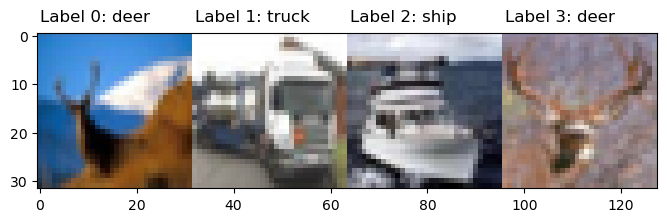

In [ ]:
preview_img, preview_label = preview_set[0]
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
preview_label = [CIFAR10_CLASSES[lab] for lab in preview_label]
print("Preview image shape:", preview_img.shape)
print("Preview label shape:", len(preview_label))

plt.figure(figsize = (8, 3))
plt.imshow(np.transpose(preview_img.numpy(), (1, 2, 0)))
for i in range(D):
    plt.text(0 + i*32, -3, f"Label {i}: {preview_label[i]}", color='black', fontsize=12)

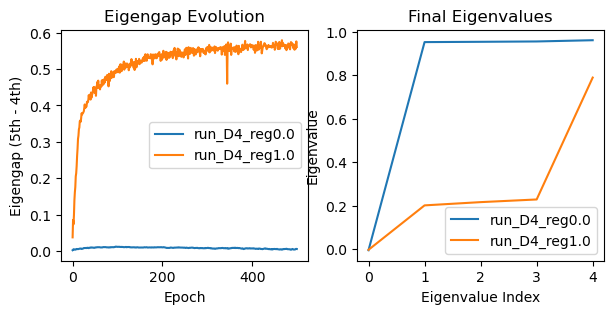

In [7]:
runs = ['results/run_D4_reg0.0', 'results/run_D4_reg1.0']
fig, axes = plt.subplots(1, 2, figsize = (7, 3))
for run in runs:
    run_path = Path(run)
    res = np.load(run_path / 'metrics.npz')
    eigvals = res['eigvals']
    gap = eigvals[:, 4] - eigvals[:, 3]
    axes[0].plot(gap, label=run_path.name)
    axes[1].plot(eigvals[-1, :5], label=run_path.name)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Eigengap (5th - 4th)")
axes[0].set_title("Eigengap Evolution")
axes[0].legend()
axes[1].set_xlabel("Eigenvalue Index")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title("Final Eigenvalues")
axes[1].legend()